# Performance Notebook



Author: Rasmus Christensen

Course: Numerical Scientific Computing

Theme: Performance NOTEBOOK 2, Parallel and Distributed Computing

Date: 07-04-2026

The Performance Notebook is split into result in here while all the function defination are to be found in mandelbort.py.

All is run by run_algorithms function which run differently depending on varaible name given to the functions, as a result of some needing warmup or benchmarking(timing) within the function calls

The Notebook is split into lectures with 

* L4,L5 being Parallel Computing
* L6,L7 being Distributed Computing

Noteably each lecture ends with a performance table with timings of the algorithm for each comparassion

## Lecture 04 Parallel Computing 1


### Milestone 1 Refractor code


In [1]:
from mandelbort import compute_mandelbrot_numba, mandelbrot_serial, run_algorithms

In [5]:
n_runs = 5

algorithms = {
"numba": lambda res: compute_mandelbrot_numba(-2, 1, -1.5, 1.5, res),
"numba_lecture4": lambda res: mandelbrot_serial(res, -2, 1, -1.5, 1.5, max_iter=100),
}
grid_res = [1024]

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

 numba with Median:0.0613s ( min =0.0608, max =0.0613)
 numba_lecture4 with Median:0.0567s ( min =0.0561, max =0.0574)


Can be seen that the 2 version indeed match based of timings

### Milestone 2-3

In [2]:
from mandelbort import mandelbrot_parallel

In [3]:
algorithms = {}
workers = [1,2,4,8,16]
grid_res = [1024]
n_runs = 3

for w in workers:
    name = f"parallel_workers_{w}"
    algorithms[name] = lambda res, w=w: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=w,n_runs=n_runs,
                                                    meta_prefix=f"Numba parellel with workers = {w}")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

 Numba parellel with workers = 1 with Median:0.0628s ( min =0.0624, max =0.0637)
 Numba parellel with workers = 2 with Median:0.0341s ( min =0.0339, max =0.0348)
 Numba parellel with workers = 4 with Median:0.0310s ( min =0.0309, max =0.0314)
 Numba parellel with workers = 8 with Median:0.0239s ( min =0.0237, max =0.0245)
 Numba parellel with workers = 16 with Median:0.0145s ( min =0.0142, max =0.0149)


We can observe that the parelle quite similiar in speed to the serial algorithm

 numba with Median:0.0613s ( min =0.0608, max =0.0613)

 numba_lecture4 with Median:0.0567s ( min =0.0561, max =0.0574)
 
 Numba parellel with workers = 1 with Median:0.0628s ( min =0.0624, max =0.0637)

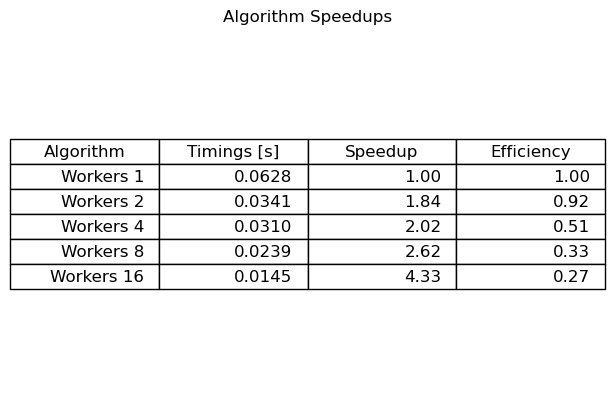

In [4]:
import matplotlib.pyplot as plt

speedups = {}
efficiency = {}
first_key = list(results[1024].keys())[0] 
reference_time = timings[1024][first_key]
for name, t in timings[1024].items():
        speedups[name] = reference_time / t
        n_workers = int(name.split("_")[-1])
        efficiency[name] = speedups[name] / n_workers

# table 
fig, axes = plt.subplots(1)

axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    e = efficiency.get(name, "")  # empty if efficiency doesn't exist
    t = timings[1024][name]
    workers = name.split("workers_")[1]
    name = f"Workers {workers}"
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
        f"{e:.2f}" if e != "" else "",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup", "Efficiency"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
axes.set_title("Algorithm Speedups")

plt.show()

Can be observed we indeed get an speedup over the multiple worker but it does not increase lets say embarssingly parrellel we dont get 8x speedup for 8 workers 

Easily observed by speed up NOT maximum speedup and effiency is not 1.00


## Lecture 05 Parallel Computing 2

## Milestone 1 Chunked mandelbort

In [6]:
workers = [1,2,4,8,16]
grid_res = [1024]
n_runs = 3
algorithms ={ "parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,n_chunks = 1,
                                                    meta_prefix=f"Numba parellel with workers = 1")
}

for w in workers:
        name = f"parallel_chunk_{w*4}x_worker_{w}"
        algorithms[name] = lambda res, w=w: mandelbrot_parallel(res, -2, 1, -1.5, 1.5, 
                                                                n_workers=w,n_runs=n_runs,n_chunks=w*4,
                                                                meta_prefix=f"Numba parellel {w*4} chunks with workers = {w}")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

 Numba parellel with workers = 1 with Median:0.0646s ( min =0.0631, max =0.0647)
 Numba parellel 4 chunks with workers = 1 with Median:0.0660s ( min =0.0655, max =0.0663)
 Numba parellel 8 chunks with workers = 2 with Median:0.0321s ( min =0.0319, max =0.0325)
 Numba parellel 16 chunks with workers = 4 with Median:0.0190s ( min =0.0189, max =0.0194)
 Numba parellel 32 chunks with workers = 8 with Median:0.0150s ( min =0.0150, max =0.0156)
 Numba parellel 64 chunks with workers = 16 with Median:0.0160s ( min =0.0139, max =0.0170)


Ran the parellel with one worker (serial), mean ofcourse also only 1 chunk

Then there is ran with [1,2,4,8,16] workers and 4x correspondly chunks

To compare between using more chunks then workers to before where we used same amount of chunks as workers

Numba parellel with workers = 1 with Median:0.0628s ( min =0.0624, max =0.0637)

 Numba parellel with workers = 2 with Median:0.0341s ( min =0.0339, max =0.0348)

 Numba parellel with workers = 4 with Median:0.0310s ( min =0.0309, max =0.0314)

 Numba parellel with workers = 8 with Median:0.0239s ( min =0.0237, max =0.0245)
 
 Numba parellel with workers = 16 with Median:0.0145s ( min =0.0142, max =0.0149)

At 8 and 4 workers it seem to improve however 1,2 and 16 seem to be similiar which may be are result of overhead being as large as what is gotten from further introducing more chunks

## Milestone 2 Optimal Chunk Size

In [7]:
from mandelbort import run_algorithms

In [8]:
n_worker_all = [1, 2, 4, 8]
n_runs = 3
grid_res = [1024]
max_cores = max_workers = max(n_worker_all)

chunks = [max_cores * x for x in [1,2,4,8,16]]

algorithms ={ "parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,n_chunks = 1,
                                                    meta_prefix=f"Numba parellel with workers = 1")
}

for c in chunks:
        name = f"parallel_chunk_{c}_workers_{max_cores}"
        algorithms[name] = lambda res, c=c: mandelbrot_parallel(res, -2, 1, -1.5, 1.5, 
                                                                n_workers=max_cores,n_runs=n_runs,n_chunks=c,
                                                                meta_prefix=f"Numba parellel {c} chunks with workers = {max_cores}")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]
T1 = timings[1024]["parallel_workers_1"]

lif = {}
speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs
    if "parallel" in name:
        # extract worker count from the name, e.g., 'parallel_lecture4_4' -> 4
        n_workers = int(name.split("workers_")[1])
        efficiency[name] = speedups[name] / n_workers
        lif[name] = n_workers * t / T1 - 1

 Numba parellel with workers = 1 with Median:0.0636s ( min =0.0634, max =0.0637)
 Numba parellel 8 chunks with workers = 8 with Median:0.0250s ( min =0.0247, max =0.0259)
 Numba parellel 16 chunks with workers = 8 with Median:0.0144s ( min =0.0143, max =0.0151)
 Numba parellel 32 chunks with workers = 8 with Median:0.0139s ( min =0.0135, max =0.0146)
 Numba parellel 64 chunks with workers = 8 with Median:0.0174s ( min =0.0164, max =0.0175)
 Numba parellel 128 chunks with workers = 8 with Median:0.0162s ( min =0.0156, max =0.0163)


It can be observered that we can improve the speedup by introducing more chunks up untill we get to many chunks resulting in more overhead, and therefore becomes slower again

We see huge decrease in time from 8 to 16 chunks and keep it low at 32 aswell however then 64,128 seems to be to much

In [9]:
import matplotlib.pyplot as plt

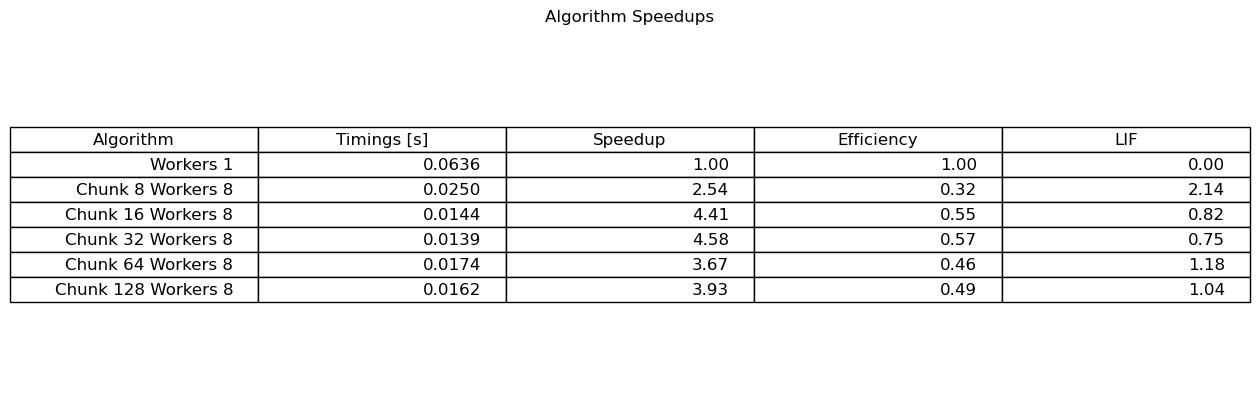

In [10]:
# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    e = efficiency.get(name, "")  # empty if efficiency doesn't exist
    l = lif.get(name, "")
    t = timings[1024][name]
    if "_chunk_" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Chunk {chunks} Workers {workers}"
    else:
        workers = name.split("workers_")[1]
        name = f"Workers {workers}"
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
        f"{e:.2f}" if e != "" else "",
        f"{l:.2f}" if l != "" else ""
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup", "Efficiency", "LIF"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

Also what we observe here of the speedup and efficiency and LIF

In [11]:
 # Choose Optimal Chunk size for max cores
chunk_lif = {k: v for k, v in lif.items() if "parallel_chunk" in k}
# Find the one with the lowest LIF
best_chunk_name = min(chunk_lif, key=chunk_lif.get)
best_lif = chunk_lif[best_chunk_name]
print(f"Best chunked algorithm: {best_chunk_name} with LIF = {best_lif:.4f}")


Best chunked algorithm: parallel_chunk_32_workers_8 with LIF = 0.7474


We Therefore choose best after LIF

## Milestone 3 Comprehensive Analysis

In [12]:
from mandelbort import compute_mandelbrot_naive,compute_mandelbrot_vectorized,compute_mandelbrot_numba,compute_mandelbrot_numba_parallel

In [13]:
grid_res = [1024]
n_runs = 3
# Extract the most optimal
n_chunks_opt= int(best_chunk_name.split("chunk_")[1].split("_")[0])
n_workers_opt = int(best_chunk_name.split("workers_")[1])

performance_note_algorithms = {
"naive": lambda res: compute_mandelbrot_naive(-2, 1, -1.5, 1.5, res),
"vectorized": lambda res: compute_mandelbrot_vectorized(-2, 1, -1.5, 1.5, res),
"numba": lambda res: compute_mandelbrot_numba(-2, 1, -1.5, 1.5, res),
"numba_parellel": lambda res: compute_mandelbrot_numba_parallel(-2, 1, -1.5, 1.5, res),
"parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,
                                                    meta_prefix="Numba parellel with workers = 1"),
f"parallel_chunk_{n_chunks_opt}_workers_{n_workers_opt}": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=n_workers_opt,n_runs=n_runs,n_chunks=n_chunks_opt,
                                                    meta_prefix=f"Numba parellel {n_chunks_opt} with workers = {n_workers_opt}"),
}

results, timings = run_algorithms(grid_res,performance_note_algorithms,n_runs=n_runs)

 naive with Median:6.8571s ( min =6.7877, max =7.3442)
 vectorized with Median:1.0903s ( min =1.0664, max =1.1271)
 numba with Median:0.0705s ( min =0.0661, max =0.0706)


c:\Numerical_SC\mandelbrot-nsc\mandelbort.py:162: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "mandelbort.py", line 141:
@njit(parallel=True)
def mandelbrot_point_numba_parallel(c):
^

  n = mandelbrot_point_numba_parallel(c)
c:\Numerical_SC\mandelbrot-nsc\mandelbort.py:162: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "mandelbort.py", line 144:
def mandelbrot_point_numba_parallel(c):
    <source elided>
    max_iter = 100
    for n in prange(max_iter):
    ^

  n = mandelbrot_point_numba_parallel(c)


 numba_parellel with Median:0.0136s ( min =0.0128, max =0.0143)
 Numba parellel with workers = 1 with Median:0.0544s ( min =0.0540, max =0.0547)
 Numba parellel 32 with workers = 8 with Median:0.0142s ( min =0.0140, max =0.0147)


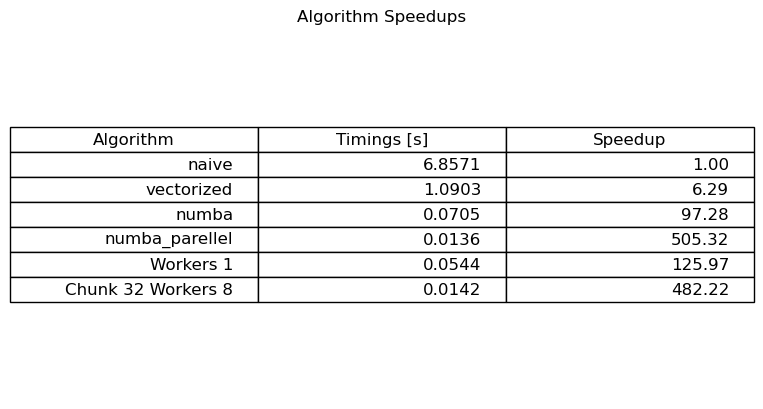

In [14]:
first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]

speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs

# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    t = timings[1024][name]
    if "_chunk_" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Chunk {chunks} Workers {workers}"
    elif "_workers_" in name:
        workers = name.split("workers_")[1]
        name = f"Workers {workers}"
    else:
        name = name
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

It can be observed we almost achieve same speedup in the 32 chunks and 8 workers to what we get in the numba_parellel with 8 workers

# Lecture 06 Distributed Computing 1

### Milestone 1 Dask Mandelbrot

In [15]:
from mandelbort import mandelbrot_dask,run_algorithms
import matplotlib.pyplot as plt

In [16]:
grid_res = [1024]
n_runs = 3
algorithms = {
"dask_chunk_1_worker_8": lambda res: mandelbrot_dask(res, -2, 1, -1.5, 1.5,
                                                        meta_prefix="dask Numba 1 x chunks with workers = 8")
}

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)


Create client local
 dask_chunk_1_worker_8 with Median:0.0886s ( min =0.0788, max =0.3570)


Dask is slower here because it introduces higher task scheduling and management overhead compared to the multiprocessing version.

 Since each Mandelbrot task is very small and fast, this overhead dominates the total runtime. As a result, performance ends up close to the single-worker case. 
 
 The multiprocessing approach has much lower overhead, making it better suited for this fine-grained workload. Dask would perform better on larger or more complex tasks where its overhead is amortized.

### Milestone 2 Chunk Size Sweep

In [17]:
chunk_dask = [1, 2, 4, 8, 16, 32, 64]
grid_res = [1024]
n_runs = 3
algorithms = {
"parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                        n_workers=1,n_runs=n_runs,
                                                        meta_prefix="Numba parellel with workers = 1")
}

for c in chunk_dask:
    name = f"dask_chunk_{c}_workers_8"
    algorithms[name] = lambda res, c=c: mandelbrot_dask(res, -2, 1, -1.5, 1.5,n_chunks=c,
                                                    meta_prefix="dask Numba {c} x chunks with workers = 8")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]
T1 = timings[1024]["parallel_workers_1"]
lif = {}
speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs
    if "parallel" or "dask" in name:
        n_workers = int(name.split("workers_")[1])
        efficiency[name] = speedups[name] / n_workers
        lif[name] = n_workers * t / T1 - 1

 Numba parellel with workers = 1 with Median:0.0554s ( min =0.0550, max =0.0584)
Create client local


c:\Users\rasm2\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 52138 instead
  warnings.warn(


 dask_chunk_1_workers_8 with Median:0.2270s ( min =0.2109, max =0.2270)
 dask_chunk_2_workers_8 with Median:0.2057s ( min =0.0541, max =0.2315)
 dask_chunk_4_workers_8 with Median:0.0715s ( min =0.0529, max =0.2177)
 dask_chunk_8_workers_8 with Median:0.0533s ( min =0.0479, max =0.1961)
 dask_chunk_16_workers_8 with Median:0.0798s ( min =0.0729, max =0.1770)
 dask_chunk_32_workers_8 with Median:0.0804s ( min =0.0763, max =0.0997)
 dask_chunk_64_workers_8 with Median:0.1558s ( min =0.1090, max =0.1741)


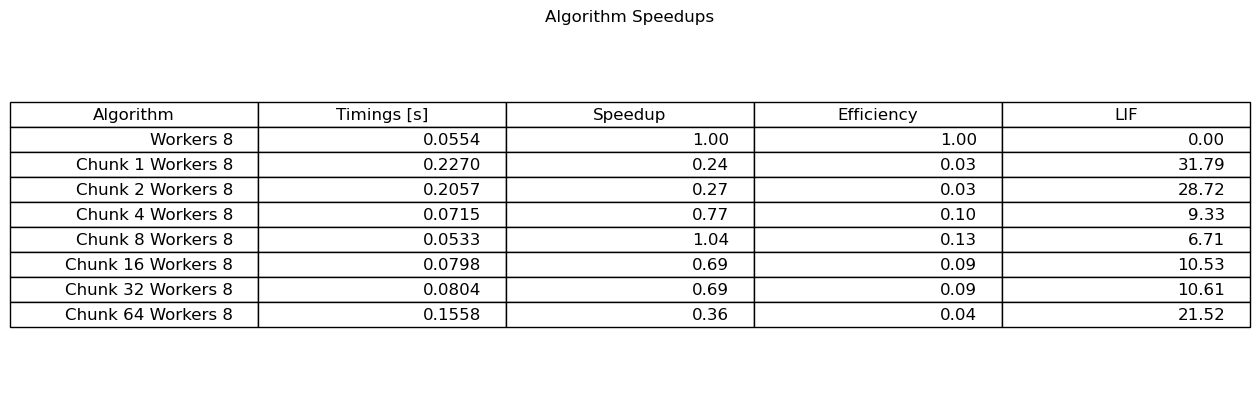

In [18]:
# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    e = efficiency.get(name, "")  # empty if efficiency doesn't exist
    l = lif.get(name, "")
    t = timings[1024][name]
    if "_chunk_" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Chunk {chunks} Workers {workers}"
    else:
        worker = name.split("workers_")[1]
        name = f"Workers {workers}"
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
        f"{e:.2f}" if e != "" else "",
        f"{l:.2f}" if l != "" else ""
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup", "Efficiency", "LIF"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

Running with 8 workers all time we can see that it gets slower if to many chunks or to little still on 1024 resulation

And the best actually is at the same chunks as workers.

I guess this to be primarily because we still how to small of a task in the 1024 grid and therefore schedule dominate in dask

### To indicate this and plot is also made of the Wall time compared to chunks

In [19]:
# Choose Optimal Chunk size for max cores
chunk_lif_dask = {k: v for k, v in lif.items() if "dask_chunk" in k}
# Find the one with the lowest LIF
best_chunk_name_dask = min(chunk_lif_dask, key=chunk_lif_dask.get)
best_lif_dask = chunk_lif_dask[best_chunk_name_dask]
n_chunks_dask_opt = best_chunk_name_dask.split("chunk_")[1].split("_")[0]
print(f"Best Dask chunked algorithm: {best_chunk_name_dask} with Chunks = {n_chunks_dask_opt} and LIF = {best_lif_dask:.4f}")

Best Dask chunked algorithm: dask_chunk_8_workers_8 with Chunks = 8 and LIF = 6.7059


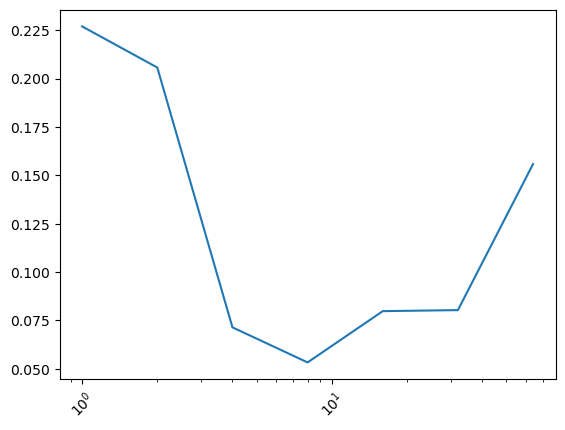

In [20]:
times = []
n_chunks = []

for name, time in timings[1024].items():
    if "dask" in name.lower():
        n_chunk = int(name.split("chunk_")[1].split("_")[0])
        n_chunks.append(n_chunk)
        times.append(time)

plt.plot(n_chunks, times)
plt.xscale("log")
plt.xticks(rotation=45)
plt.show()

### Milestone 3  Full Benchmark


 naive with Median:8.6900s ( min =8.5896, max =8.7658)
 vectorized with Median:1.3540s ( min =1.2908, max =1.3963)
 numba with Median:0.0591s ( min =0.0547, max =0.0637)
 numba_parellel with Median:0.0148s ( min =0.0145, max =0.0354)
 Numba parellel with workers = 1 with Median:0.0558s ( min =0.0545, max =0.0577)
 Numba parellel 16 with workers = 8 with Median:0.0119s ( min =0.0115, max =2.5183)
Create client local


c:\Users\rasm2\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 53112 instead
  warnings.warn(


 dask_chunk_8_workers_8 with Median:0.0793s ( min =0.0649, max =0.3352)


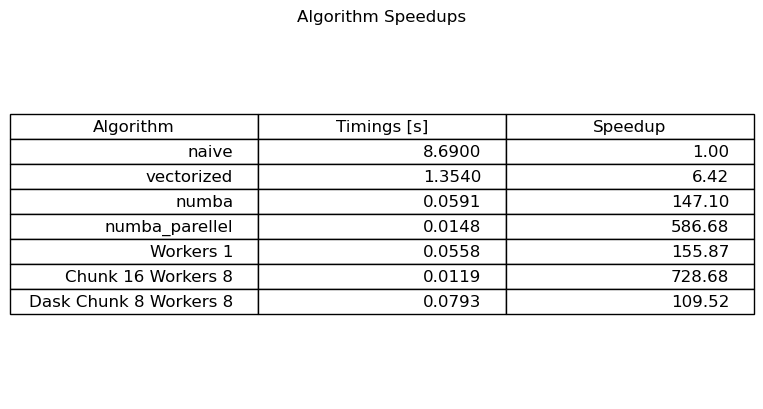

In [21]:
n_chunks_opt_dask= int(best_chunk_name_dask.split("chunk_")[1].split("_")[0])
n_workers_opt_dask = int(best_chunk_name_dask.split("workers_")[1])
for name in list(performance_note_algorithms):
    if "dask" in name:
        performance_note_algorithms.pop(name)
performance_note_algorithms[f"dask_chunk_{n_chunks_opt_dask}_workers_{n_workers_opt_dask}"] = \
    lambda res: mandelbrot_dask(
        res, -2, 1, -1.5, 1.5,
        n_chunks=n_chunks_opt_dask,
        meta_prefix=f"dask Numba {n_chunks_opt_dask} x chunks with workers = {n_workers_opt_dask}"
    )

results, timings = run_algorithms(grid_res,performance_note_algorithms,n_runs=n_runs)

first_key = list(results[1024].keys())[0] 
naive_time = timings[1024][first_key]

speedups = {}
efficiency = {}
for name, t in timings[1024].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs

# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    t = timings[1024][name]
    if "dask_chunk" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Dask Chunk {chunks} Workers {workers}"
    elif "_chunk_" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Chunk {chunks} Workers {workers}"
    elif "_workers_" in name:
        workers = name.split("workers_")[1]
        name = f"Workers {workers}"
    else:
        name = name
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

Again to Compare like we did in previous lectures, where we clearly observe that the Dask is much slower then the parallel version and closer to serial numba

## Lecture 7 Distributed Computing 2


### Milestone 1 DASK on Strato

In [15]:
from mandelbort import mandelbrot_dask, run_algorithms,mandelbrot_parallel

In [16]:
grid_res_times = 4096
grid_res = [grid_res_times]
chunk_dask = [1, 2, 4, 8, 16, 32, 64]
n_runs = 3
algorithms ={ "parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,n_chunks = 1,
                                                    meta_prefix=f"Numba parellel with workers = 1")
}
for c in chunk_dask:
        name = f"dask_chunk_{c}_workers_8"
        algorithms[name] = lambda res, c=c: mandelbrot_dask(res, -2, 1, -1.5, 1.5,n_chunks=c,
                                                        meta_prefix="dask Numba {c} x chunks with workers = 8")

results, timings = run_algorithms(grid_res,algorithms,n_runs=n_runs)

first_key = list(results[grid_res_times].keys())[0] 
naive_time = timings[grid_res_times][first_key]
T1 = timings[grid_res_times]["parallel_workers_1"]
lif = {}
speedups = {}
efficiency = {}
for name, t in timings[grid_res_times].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs
    if "parallel" or "dask" in name:
        n_workers = int(name.split("workers_")[1])
        efficiency[name] = speedups[name] / n_workers
        lif[name] = n_workers * t / T1 - 1

 Numba parellel with workers = 1 with Median:0.9834s ( min =0.9759, max =1.0053)
Create client local
 dask_chunk_1_workers_8 with Median:1.2643s ( min =1.1038, max =1.5890)
 dask_chunk_2_workers_8 with Median:0.6751s ( min =0.5040, max =0.7904)
 dask_chunk_4_workers_8 with Median:0.4925s ( min =0.4833, max =0.8078)
 dask_chunk_8_workers_8 with Median:0.4538s ( min =0.3991, max =0.5760)
 dask_chunk_16_workers_8 with Median:0.3558s ( min =0.3216, max =0.4187)
 dask_chunk_32_workers_8 with Median:0.3852s ( min =0.3486, max =0.4095)
 dask_chunk_64_workers_8 with Median:0.4370s ( min =0.3962, max =0.4455)


Here the result are from running locally with a resulation of 4096 now

Which why the times also are quite a bit large then we say in previous lectures with 1024

It can be observed that that 16 to 32 seems to be the right amount of chunks not to many or to little

## Change to Strato

We then change client to the ip of the VM

Have set it up with two images for workers using 	AAU.CPU.b.2-4

Where i run it with 2 workers

dask worker 10.92.y.x:8786 --nworkers -1 --nthreads 1 

dask worker 10.92.y.x:8786 --nworkers -1 --nthreads 1

Wierdly i don't see any improvement to the strato from my local, have tried running multiple times and also creating the instances over again with the 2 worker (images) here but later in the comphresion result it seems that 

In [17]:
# Choose Optimal Chunk size for max cores
chunk_lif_dask = {k: v for k, v in lif.items() if "dask_chunk" in k}
# Find the one with the lowest LIF
best_chunk_name_dask = min(chunk_lif_dask, key=chunk_lif_dask.get)
best_lif_dask = chunk_lif_dask[best_chunk_name_dask]
n_chunks_dask_opt = best_chunk_name_dask.split("chunk_")[1].split("_")[0]
print(f"Best Dask chunked algorithm: {best_chunk_name_dask} with Chunks = {n_chunks_dask_opt} and LIF = {best_lif_dask:.4f}")

Best Dask chunked algorithm: dask_chunk_16_workers_8 with Chunks = 16 and LIF = 1.8945


## Comparision Table

 naive with Median:195.6831s ( min =195.6831, max =195.6831)
 vectorized with Median:24.5789s ( min =24.5789, max =24.5789)
 numba with Median:0.8759s ( min =0.8759, max =0.8759)
 numba_parellel with Median:0.2937s ( min =0.2937, max =0.2937)
 Numba parellel with workers = 1 with Median:0.9524s ( min =0.9524, max =0.9524)
 Numba parellel 16 with workers = 8 with Median:3.1784s ( min =3.1784, max =3.1784)
Create client local


c:\Users\rasm2\miniforge3\envs\nsc2026\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 61213 instead
  warnings.warn(
c:\Users\rasm2\miniforge3\envs\nsc2026\Lib\contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (2.35s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


 dask_chunk_16_workers_8 with Median:1.4421s ( min =1.4421, max =1.4421)


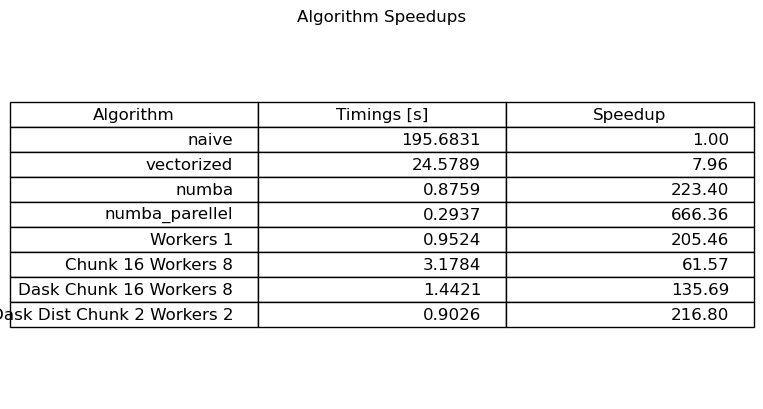

In [28]:
n_chunks_opt_dask= int(best_chunk_name_dask.split("chunk_")[1].split("_")[0])
n_workers_opt_dask = int(best_chunk_name_dask.split("workers_")[1])

grid_res_times = 4096
grid_res = [grid_res_times]
n_runs = 1

performance_note_algorithms = {
"naive": lambda res: compute_mandelbrot_naive(-2, 1, -1.5, 1.5, res),
"vectorized": lambda res: compute_mandelbrot_vectorized(-2, 1, -1.5, 1.5, res),
"numba": lambda res: compute_mandelbrot_numba(-2, 1, -1.5, 1.5, res),
"numba_parellel": lambda res: compute_mandelbrot_numba_parallel(-2, 1, -1.5, 1.5, res),
"parallel_workers_1": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=1,n_runs=n_runs,
                                                    meta_prefix="Numba parellel with workers = 1"),
f"parallel_chunk_{n_chunks_opt}_workers_{n_workers_opt}": lambda res: mandelbrot_parallel(res, -2, 1, -1.5, 1.5,
                                                    n_workers=n_workers_opt,n_runs=n_runs,n_chunks=n_chunks_opt,
                                                    meta_prefix=f"Numba parellel {n_chunks_opt} with workers = {n_workers_opt}"),
}

performance_note_algorithms[f"dask_chunk_{n_chunks_opt_dask}_workers_{n_workers_opt_dask}"] = \
    lambda res: mandelbrot_dask(
        res, -2, 1, -1.5, 1.5,
        n_chunks=n_chunks_opt_dask,
        meta_prefix=f"dask Numba {n_chunks_opt_dask} x chunks with workers = {n_workers_opt_dask}"
    )

results, timings = run_algorithms(grid_res,performance_note_algorithms,n_runs=n_runs)

first_key = list(results[grid_res_times].keys())[0] 
naive_time = timings[grid_res_times][first_key]

timings[grid_res_times]["dask_dist_chunk_2_workers_2"] = 0.9026
speedups = {}
efficiency = {}
for name, t in timings[grid_res_times].items():
    speedups[name] = naive_time / t
    # compute efficiency only for parallel runs

# create figure
fig, axes = plt.subplots(1)

# speedup table 
axes.axis("off")
table_data = []
for name in speedups.keys():
    s = speedups[name]
    t = timings[grid_res_times][name]
    if "dask_dist" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Dask Dist Chunk {chunks} Workers {workers}"
    if "dask_chunk" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Dask Chunk {chunks} Workers {workers}"
    elif "_chunk_" in name:
        chunks = name.split("chunk_")[1].split("_")[0]
        workers = name.split("workers_")[1]
        name = f"Chunk {chunks} Workers {workers}"
    elif "_workers_" in name:
        workers = name.split("workers_")[1]
        name = f"Workers {workers}"
    else:
        name = name
    table_data.append([
        name,
        f"{t:.4f}",
        f"{s:.2f}",
    ])
    table = axes.table(
        cellText=table_data,
        colLabels=["Algorithm","Timings [s]", "Speedup"],
        loc="center"
    )
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.5, 1.5)
axes.set_title("Algorithm Speedups")

# im0 = axes[2].imshow(results[1024]["numba_lecture4"], cmap="hot")
# numba_lecture_time_1024= timings[1024]["numba_lecture4"]
# axes[2].set_title(f"Numba lecture 4 Mandelbrot\n Median time: {numba_lecture_time_1024:.2f} s")
# axes[2].axis("off")
# fig.colorbar(im0, ax=axes[2], fraction=0.046, pad=0.04)

plt.show()

Here we can actually see an improvement in the Strato(distributed, dist) compared to the local run dask. Cant seem to understand why the local is so much slower this time running have a suspicion that it might be becuase the client is not total setup and therefore still is warming up

However what we can see is that the dask here becomes alot faster then the chunk parallel of 16 and 8 workers
however still does not compare to the the numba parallel whhich still out performs alot

